In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [47]:
df = pd.read_csv("kc_house_data.csv")
df.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


In [48]:
print(df.isnull().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       2
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [49]:
""" we will use
sqft_living
bedrooms
bathrooms
floors
condition
TARGET"
price """

' we will use\nsqft_living\nbedrooms\nbathrooms\nfloors\ncondition\nTARGET"\nprice '

In [50]:
X = df[[
    'sqft_living',
    'bedrooms',
    'bathrooms',
    'floors',
    'condition'
]]

y = df['price']

In [51]:
#TRAINING
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
#fit trans
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
batch_model = LinearRegression()
batch_model.fit(X_train, y_train)
batch_predictions = batch_model.predict(X_test)

In [54]:
batch_mse = mean_squared_error(y_test, batch_predictions)

batch_r2 = r2_score(y_test, batch_predictions)

print("Batch Learning MSE:", batch_mse)
print("Batch Learning R2 Score:", batch_r2)

Batch Learning MSE: 72792612949.22197
Batch Learning R2 Score: 0.5184932132566571


In [55]:
#coef
print(batch_model.coef_)
#intercept
print(batch_model.intercept_)

[   304.47585251 -59597.06732842  14372.07584635  15383.25661895
  51917.87004677]
-123307.8051558279


In [56]:
#Apply ridge and lasso regression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_predictions = ridge_model.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_r2 = r2_score(y_test, ridge_predictions)
print("Ridge Regression MSE:", ridge_mse)
print("Ridge Regression R2 Score:", ridge_r2)
print("Ridge Coefficients:", ridge_model.coef_)

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
lasso_predictions = lasso_model.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_r2 = r2_score(y_test, lasso_predictions)
print("Lasso Regression MSE:", lasso_mse)
print("Lasso Regression R2 Score:", lasso_r2)
print("Lasso Coefficients:", lasso_model.coef_)

Ridge Regression MSE: 72793233795.46881
Ridge Regression R2 Score: 0.518489106498165
Ridge Coefficients: [276199.88159157 -55490.41837998  11043.29941457   8349.38982856
  33831.70418215]
Lasso Regression MSE: 72792617342.40298
Lasso Regression R2 Score: 0.5184931841967512
Lasso Coefficients: [276242.16921465 -55505.97897419  11019.96098851   8349.99058373
  33833.62408381]


In [57]:
X_initial = X_train_scaled[:5000]
y_initial = y_train.iloc[:5000]

X_stream = X_train_scaled[5000:]
y_stream = y_train.iloc[5000:]

In [58]:
#Apply online training

sgd_model = SGDRegressor(max_iter=1000, tol=1e-3)
sgd_model.fit(X_initial, y_initial)
sgd_predictions = sgd_model.predict(X_test_scaled)
sgd_mse = mean_squared_error(y_test, sgd_predictions)
sgd_r2 = r2_score(y_test, sgd_predictions)
print("SGD Regression MSE:", sgd_mse)
print("SGD Regression R2 Score:", sgd_r2)

SGD Regression MSE: 73108960562.64981
SGD Regression R2 Score: 0.5164006448398339


In [59]:
incremental_model = SGDRegressor(
    learning_rate='constant',
    eta0=0.000001,
    max_iter=1,
    tol=None,
    random_state=42
)

In [60]:
#initial training
incremental_model.partial_fit(X_initial, y_initial)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",None
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [61]:
#now lets stream new data
batch_size = 500

for i in range(0, len(X_stream), batch_size):

    X_batch = X_stream[i:i+batch_size]
    y_batch = y_stream.iloc[i:i+batch_size]

    incremental_model.partial_fit(X_batch, y_batch)

    print(f"Updated using rows {i} to {i+batch_size}")

Updated using rows 0 to 500
Updated using rows 500 to 1000
Updated using rows 1000 to 1500
Updated using rows 1500 to 2000
Updated using rows 2000 to 2500
Updated using rows 2500 to 3000
Updated using rows 3000 to 3500
Updated using rows 3500 to 4000
Updated using rows 4000 to 4500
Updated using rows 4500 to 5000
Updated using rows 5000 to 5500
Updated using rows 5500 to 6000
Updated using rows 6000 to 6500
Updated using rows 6500 to 7000
Updated using rows 7000 to 7500
Updated using rows 7500 to 8000
Updated using rows 8000 to 8500
Updated using rows 8500 to 9000
Updated using rows 9000 to 9500
Updated using rows 9500 to 10000
Updated using rows 10000 to 10500
Updated using rows 10500 to 11000
Updated using rows 11000 to 11500
Updated using rows 11500 to 12000
Updated using rows 12000 to 12500


In [62]:
"""
For every mini-batch:
1. Model predicts
2. Finds error
3. Adjusts weights slightly
4. Improves model --- without retraining"""

'\nFor every mini-batch:\n1. Model predicts\n2. Finds error\n3. Adjusts weights slightly\n4. Improves model --- without retraining'

In [63]:
#final
incremental_predictions = incremental_model.predict(X_test_scaled)

In [64]:
#evaluation
incremental_mse = mean_squared_error(
    y_test,
    incremental_predictions
)

incremental_r2 = r2_score(
    y_test,
    incremental_predictions
)

print("Incremental Learning MSE:", incremental_mse)
print("Incremental Learning R2 Score:", incremental_r2)

Incremental Learning MSE: 438291867755.4134
Incremental Learning R2 Score: -1.8992022727067526


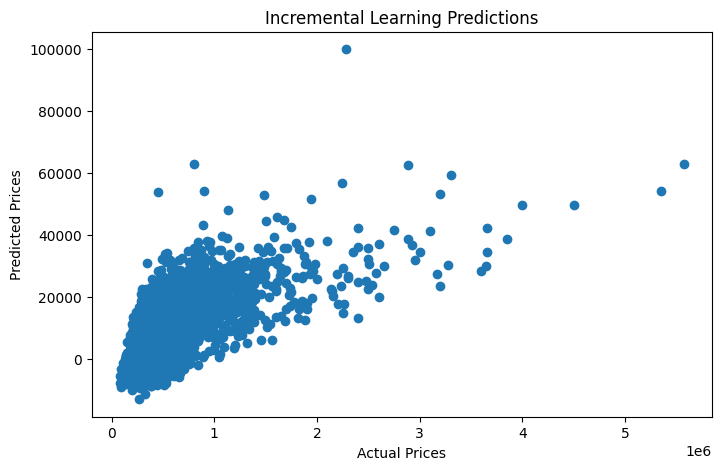

In [65]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, incremental_predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Incremental Learning Predictions")

plt.show()

In [69]:
#final comparison

print("FINAL COMPARISON")
print("\nBatch Learning R2 Score:")
print(batch_r2)

print("\nIncremental Learning R2 Score:")
print(incremental_r2)

print("\nRidge Regression R2 Score:")
print(ridge_r2)

print("\nLasso Regression R2 Score:")
print(lasso_r2)

print("\nSGD Regression R2 Score:")
print(sgd_r2)

print("\nBatch Learning MSE:")
print(batch_mse)

print("\nIncremental Learning MSE:")
print(incremental_mse)

print("\nRidge Regression MSE:")
print(ridge_mse)

print("\nLasso Regression MSE:")
print(lasso_mse)

print("\nSGD Regression MSE:")
print(sgd_mse)

FINAL COMPARISON

Batch Learning R2 Score:
0.5184932132566571

Incremental Learning R2 Score:
-1.8992022727067526

Ridge Regression R2 Score:
0.518489106498165

Lasso Regression R2 Score:
0.5184931841967512

SGD Regression R2 Score:
0.5164006448398339

Batch Learning MSE:
72792612949.22197

Incremental Learning MSE:
438291867755.4134

Ridge Regression MSE:
72793233795.46881

Lasso Regression MSE:
72792617342.40298

SGD Regression MSE:
73108960562.64981


In [67]:
df['expensive_house'] = np.where(
    df['price'] > df['price'].median(),
    1,
    0
)

In [70]:
#LOGISTIC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# features
X = df[[
    'sqft_living',
    'bedrooms',
    'bathrooms',
    'floors',
    'condition'
]]

# target
y = df['expensive_house']

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# scale it
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# choose the model
model = LogisticRegression()

# Train
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.7441591487393014

Confusion Matrix
[[1685  451]
 [ 655 1532]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      2136
           1       0.77      0.70      0.73      2187

    accuracy                           0.74      4323
   macro avg       0.75      0.74      0.74      4323
weighted avg       0.75      0.74      0.74      4323

